# MDMR R Notebook

This notebook demonstrates basic usage of the `mdmr` package, including visualization and model fitting.

In [ ]:
library(mdmr)
library(ggplot2)

y <- mdmr::y
y <- read.csv("../data/covid_regional_timeseries")


,Y1,Y2,Y3,Y4
,<dbl>,<dbl>,<dbl>,<dbl>
1,-6.1321001,-11.210444,-7.283991,-16.075637
2,16.2922322,7.415729,-5.656067,12.150740
3,15.9534579,13.000213,-3.744846,-3.317547
4,-16.3264156,-1.952344,4.994592,9.167856
5,0.3482551,-1.353144,1.710518,0.384896
6,-9.1254934,-2.152148,-3.419737,-7.484200


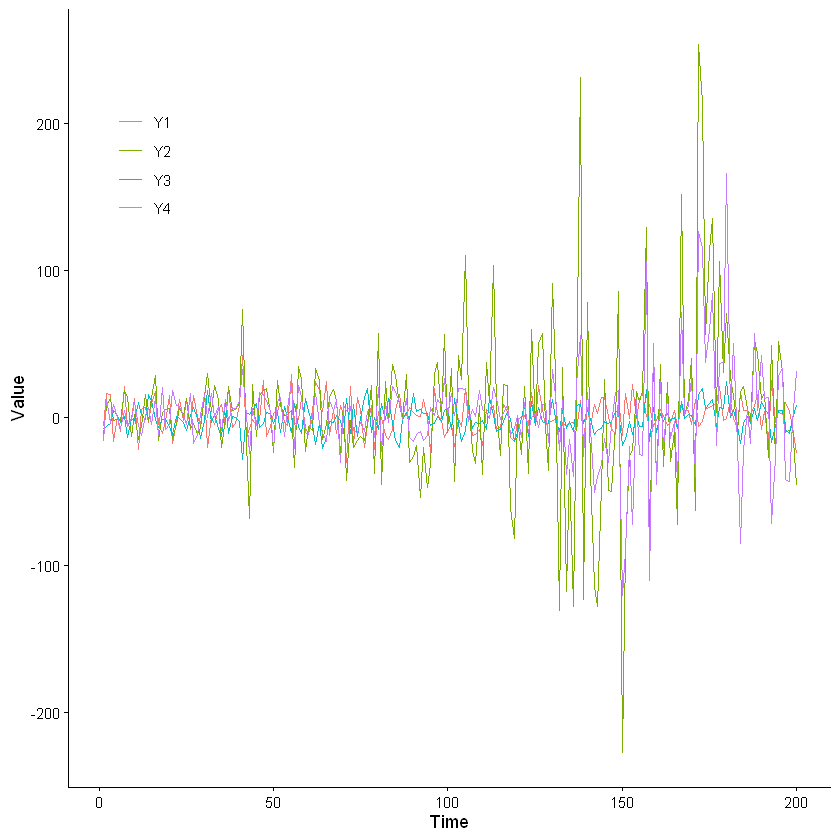

In [2]:
head(mdmr::y)
long_df <- stack(mdmr::y)
long_df$obs <- rep(seq_len(nrow(mdmr::y)), times = ncol(mdmr::y))
names(long_df) <- c("Value", "name", "Time")
long_df |> 
  ggplot2::ggplot(ggplot2::aes(x = Time, y = Value, colour = name)) +
  ggplot2::geom_line() +
  ggplot2::theme_classic() +
  ggplot2::theme(legend.position = c(.1, .8), legend.title = ggplot2::element_blank())

## 2. Fit the MDM model

In [ ]:
res <- mdm(data_input = y, method = "hc")

Running bnlearn::hc() with MDM custom score...



$adj_mat
   Y1 Y2 Y3 Y4
Y1  0  1  0  0
Y2  0  0  0  0
Y3  1  0  0  1
Y4  0  1  0  0

$DF
$DF$lpldet
           [,1]      [,2]      [,3]      [,4]
 [1,] -748.1076 -830.4390 -698.2228 -766.6977
 [2,] -746.5531 -829.4965 -697.6101 -765.3601
 [3,] -745.0180 -828.6328 -697.0003 -764.0511
 [4,] -743.5017 -827.8492 -696.3934 -762.7700
 [5,] -742.0037 -827.1471 -695.7893 -761.5164
 [6,] -740.5237 -826.5277 -695.1879 -760.2896
 [7,] -739.0613 -825.9922 -694.5891 -759.0892
 [8,] -737.6161 -825.5420 -693.9929 -757.9149
 [9,] -736.1881 -825.1779 -693.3992 -756.7662
[10,] -734.7770 -824.9012 -692.8079 -755.6430
[11,] -733.3826 -824.7126 -692.2190 -754.5451
[12,] -732.0050 -824.6129 -691.6325 -753.4725
[13,] -730.6440 -824.6029 -691.0483 -752.4253
[14,] -729.2997 -824.6832 -690.4663 -751.4038
[15,] -727.9722 -824.8542 -689.8867 -750.4086
[16,] -726.6615 -825.1165 -689.3093 -749.4402
[17,] -725.3677 -825.4705 -688.7343 -748.4997
[18,] -724.0912 -825.9167 -688.1616 -747.5882
[19,] -722.8322 -826.4556 

Warning message in ggraph::geom_node_label(ggplot2::aes(label = name), label.size = NA, :
"Ignoring unknown parameters: `label.size`"


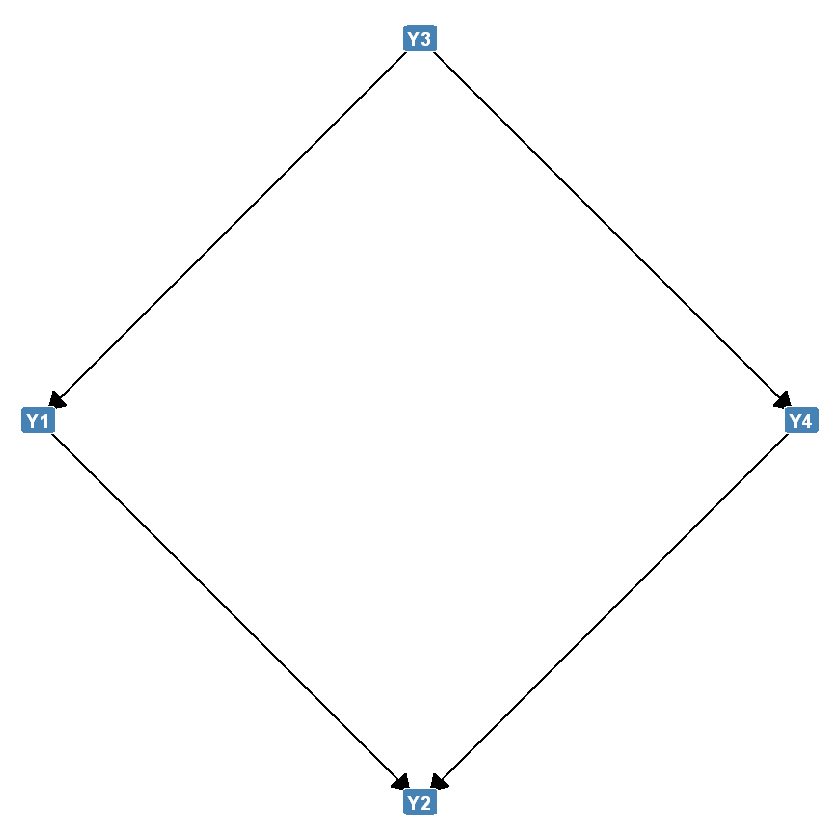

In [4]:
plot_dag(res, type = "graph")

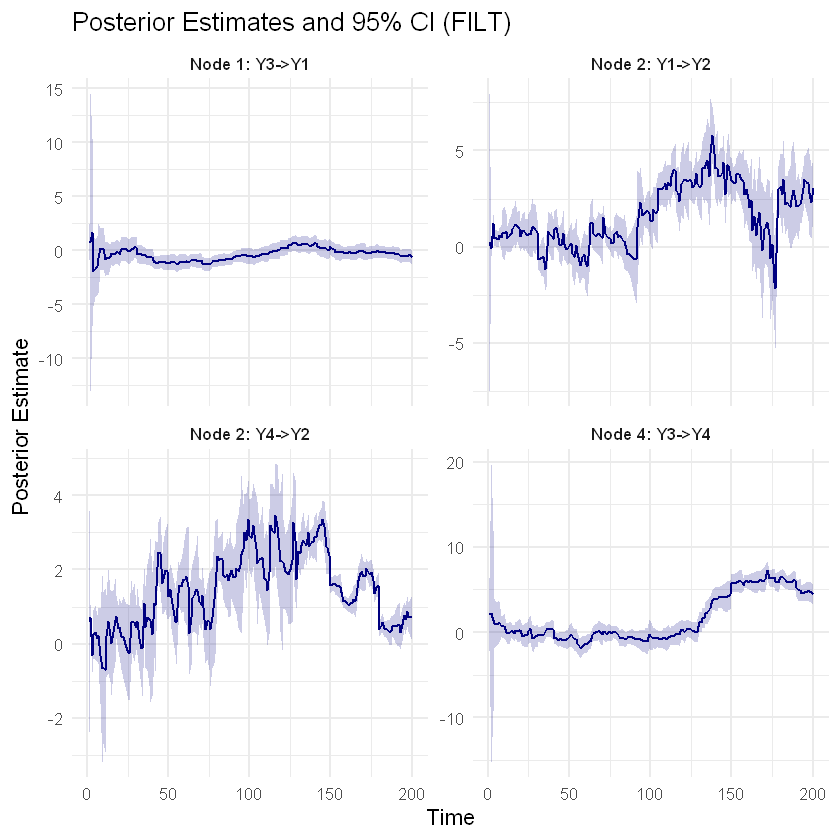

In [6]:
plot_arcs(res, type = "connections", distribution = "filt", ci_level = 0.95)